In [3]:
# ============================================================
# استخراج بيانات حقيقية للرعاية الصحية والاقتصاد
# للجزائر، تركيا، فرنسا (2016-2024)
# المصادر: World Bank API, WHO GHO API, OECD
# ============================================================

!pip install wbgapi
import pandas as pd
import numpy as np
import wbgapi as wb
import requests
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. بيانات World Bank (حقيقية)
# ============================================================

countries = ['DZA', 'TUR', 'FRA']
country_names = {'DZA': 'Algeria', 'TUR': 'Turkey', 'FRA': 'France'}
years = list(range(2016, 2025))  # 2016-2024

# المؤشرات المتاحة في World Bank
indicators_wb = {
    'NY.GDP.PCAP.PP.KD': 'GDP_per_capita_PPP',           # نصيب الفرد من الناتج المحلي
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_GDP',   # الإنفاق الصحي (% من الناتج المحلي)
    'SH.XPD.CHEX.PC.CD': 'health_expenditure_per_capita_USD',  # الإنفاق الصحي للفرد (دولار)
    'SH.MED.PHYS.ZS': 'physicians_per_1000',             # الأطباء لكل 1000 نسمة
    'SH.STA.BEDS.ZS': 'hospital_beds_per_1000',          # أسرة المستشفيات لكل 1000
    'IT.NET.USER.ZS': 'internet_users_pct',              # مستخدمي الإنترنت (%)
    'GB.XPD.RSDV.GD.ZS': 'R_and_D_expenditure_pct_GDP',  # إنفاق البحث والتطوير
    'SP.DYN.LE00.IN': 'life_expectancy',                 # متوسط العمر المتوقع
    'SP.POP.TOTL': 'total_population',                   # إجمالي السكان
}

print("جاري جلب بيانات World Bank...")
df_wb_list = []

for indicator_code, indicator_name in indicators_wb.items():
    try:
        # جلب البيانات من World Bank API
        data = wb.data.DataFrame(indicator_code, countries, time=years, numericTimeKeys=True, labels=False)
        data = data.reset_index()
        data = data.melt(id_vars=['economy'], var_name='year', value_name=indicator_name)
        data['country_code'] = data['economy']
        data['country'] = data['country_code'].map(country_names)
        df_wb_list.append(data[['country_code', 'country', 'year', indicator_name]])
    except Exception as e:
        print(f"خطأ في جلب {indicator_code}: {e}. سأضيف عمودًا فارغًا لهذا المؤشر.")
        # If fetching fails, create a DataFrame with NaN values for this indicator
        empty_data = pd.DataFrame({
            'country_code': [c for c in countries for _ in years],
            'country': [country_names[c] for c in countries for _ in years],
            'year': years * len(countries),
            indicator_name: np.nan
        })
        df_wb_list.append(empty_data)

# دمج جميع مؤشرات World Bank
if df_wb_list:
    df_wb = df_wb_list[0]
    for df_item in df_wb_list[1:]:
        df_wb = df_wb.merge(df_item, on=['country_code', 'country', 'year'], how='outer')
else:
    print("⚠️ لم يتم جلب أي بيانات من World Bank. إنشاء DataFrame فارغ.")
    df_wb = pd.DataFrame(columns=['country_code', 'country', 'year'] + list(indicators_wb.values()))

print(f"✅ تم جلب {len(df_wb)} صف من World Bank")
print(df_wb.head())

# ============================================================
# 2. بيانات WHO Global Health Observatory (حقيقية)
# ============================================================

print("\nجاري جلب بيانات WHO GHO...")

# WHO GHO OData API
WHO_API_BASE = "https://ghoapi.azureedge.net/api"

# المؤشرات المتاحة في WHO GHO
who_indicators = {
    'OECD_Health_Expenditure': 'SHA_11_12_13_14_15_16_17_18_19_1_10',  # إنفاق صحي
    'Hospital_Beds': 'MEDICALDOCTORS',  # عدد الأطباء (مؤشر بديل)
}

def fetch_who_indicator(indicator_code):
    """جلب بيانات مؤشر من WHO GHO API"""
    url = f"{WHO_API_BASE}/{indicator_code}"
    try:
        response = requests.get(url, timeout=30)
        if response.status_code == 200:
            data = response.json()
            records = []
            for item in data.get('value', []):
                if item.get('SpatialDimType') == 'COUNTRY':
                    records.append({
                        'country_code': item.get('SpatialDim'),
                        'year': int(item.get('TimeDim')),
                        'value': item.get('NumericValue'),
                        'indicator': indicator_code
                    })
            return pd.DataFrame(records)
    except Exception as e:
        print(f"خطأ في جلب {indicator_code}: {e}")
    return pd.DataFrame()

# جلب بيانات WHO (قد تكون محدودة للدول المختارة)
df_who_list = []
for name, code in who_indicators.items():
    df_temp = fetch_who_indicator(code)
    if not df_temp.empty:
        df_temp['indicator_name'] = name
        df_who_list.append(df_temp)

if df_who_list:
    df_who = pd.concat(df_who_list, ignore_index=True)
    print(f"✅ تم جلب {len(df_who)} صف من WHO")
else:
    print("⚠️ لم يتم العثور على بيانات WHO للمؤشرات المحددة")
    df_who = pd.DataFrame()

# ============================================================
# 3. بيانات OECD (حقيقية - متاحة للدول الأعضاء)
# ============================================================

print("\nجاري جلب بيانات OECD...")

# OECD.Stat API (متاح للدول الأعضاء فقط: فرنسا وتركيا)
# الجزائر ليست عضوة في OECD
OECD_API_BASE = "https://stats.oecd.org/SDMX-JSON/data"

def fetch_oecd_health_data():
    """جلب بيانات صحية من OECD"""
    # Health Expenditure and Financing
    dataset = "SHA"
    try:
        # محاولة جلب بيانات الإنفاق الصحي
        url = f"{OECD_API_BASE}/{dataset}/ALL.ALL.ALL/all?startPeriod=2016&endPeriod=2024"
        response = requests.get(url, timeout=30)
        if response.status_code == 200:
            print("✅ تم جلب بيانات OECD")
            return response.json()
    except Exception as e:
        print(f"خطأ في جلب OECD: {e}")
    return None

oecd_data = fetch_oecd_health_data()

# ============================================================
# 4. حساب متغيرات مشتقة (من البيانات الحقيقية)
# ============================================================

print("\nجاري حساب المتغيرات المشتقة...")

# التأكد من أن البيانات رقمية
numeric_cols = ['GDP_per_capita_PPP', 'health_expenditure_pct_GDP',
                'health_expenditure_per_capita_USD', 'physicians_per_1000',
                'hospital_beds_per_1000', 'internet_users_pct',
                'R_and_D_expenditure_pct_GDP', 'life_expectancy', 'total_population']

for col in numeric_cols:
    if col in df_wb.columns:
        df_wb[col] = pd.to_numeric(df_wb[col], errors='coerce')

# حساب التكلفة التقريبية للمريض (من الإنفاق الصحي الإجمالي)
# هذه تقدير وليست محاكاة - تعتمد على بيانات حقيقية
df_wb['cost_per_patient_USD'] = df_wb['health_expenditure_per_capita_USD']

# حساب مؤشر تبني التكنولوجيا (من بيانات حقيقية)
# هذا مؤشر مركب ولكن مبني على بيانات حقيقية
df_wb['tech_readiness_index'] = (
    df_wb['internet_users_pct'].fillna(0) * 0.4 +
    df_wb['R_and_D_expenditure_pct_GDP'].fillna(0) * 100 * 0.3 +
    df_wb['hospital_beds_per_1000'].fillna(0) * 10 * 0.3
)

# ============================================================
# 5. التحقق من البيانات ومعالجة القيم المفقودة
# ============================================================

print("\n=== تقرير البيانات ===")
print(f"إجمالي الصفوف: {len(df_wb)}")
print(f"الفترة الزمنية: {df_wb['year'].min()} - {df_wb['year'].max()}")
print(f"الدول: {df_wb['country'].unique().tolist()}")

# نسبة القيم المفقودة لكل متغير
print("\nنسبة القيم المفقودة:")
for col in df_wb.columns:
    if col not in ['country_code', 'country', 'year']:
        missing_pct = df_wb[col].isna().mean() * 100
        print(f"  {col}: {missing_pct:.1f}%")

# معالجة القيم المفقودة بالاستيفاء الخطي (للدول)
print("\nجاري معالجة القيم المفقودة بالاستيفاء الخطي...")
for col in numeric_cols:
    if col in df_wb.columns:
        for country in countries:
            mask = df_wb['country_code'] == country
            df_wb.loc[mask, col] = df_wb.loc[mask, col].interpolate(method='linear', limit_direction='both')

# ============================================================
# 6. حفظ البيانات النهائية
# ============================================================

# إنشاء المتغيرات اللوغاريتمية
df_wb['log_GDP_per_capita'] = np.log(df_wb['GDP_per_capita_PPP'])
df_wb['log_cost_per_patient'] = np.log(df_wb['cost_per_patient_USD'])
df_wb['log_health_expenditure'] = np.log(df_wb['health_expenditure_pct_GDP'] + 0.01)

# حفظ كـ CSV
output_file = 'healthcare_panel_REAL_DATA_2016_2024.csv'
df_wb.to_csv(output_file, index=False)
print(f"\n✅ تم حفظ البيانات في: {output_file}")

# ============================================================
# 7. إحصائيات وصفية
# ============================================================

print("\n=== إحصائيات وصفية ===")
print(df_wb.groupby('country')[['GDP_per_capita_PPP', 'health_expenditure_per_capita_USD',
                                 'physicians_per_1000', 'internet_users_pct']].describe())

print("\n=== ملاحظات هامة ===")
print("1. هذه البيانات حقيقية من World Bank API")
print("2. بعض القيم المفقودة تم استيفاؤها بالطريقة الخطية")
print("3. 'cost_per_patient' هو تقدير من الإنفاق الصحي للفرد")
print("4. 'tech_readiness_index' مؤشر مركب من بيانات حقيقية")
print("5. للحصول على بيانات AI محددة، يجب الرجوع إلى مصادر متخصصة")

جاري جلب بيانات World Bank...
خطأ في جلب SH.STA.BEDS.ZS: APIError: JSON decoding error (https://api.worldbank.org/v2/en/sources/2/series/SH.STA.BEDS.ZS/country/DZA;TUR;FRA/time/YR2016;YR2017;YR2018;YR2019;YR2020;YR2021;YR2022;YR2023;YR2024?per_page=1000&page=1&format=json). سأضيف عمودًا فارغًا لهذا المؤشر.
✅ تم جلب 27 صف من World Bank
  country_code  country  year  GDP_per_capita_PPP  health_expenditure_pct_GDP  \
0          DZA  Algeria  2016        15511.685877                    6.000809   
1          DZA  Algeria  2017        15427.664189                    5.948454   
2          DZA  Algeria  2018        15343.426122                    5.932393   
3          DZA  Algeria  2019        15199.198997                    5.417321   
4          DZA  Algeria  2020        14194.155748                    5.638308   

   health_expenditure_per_capita_USD  physicians_per_1000  \
0                         265.534912                1.819   
1                         270.932312                  

In [ ]:
import os
from google.colab import files

file_name = 'healthcare_panel_REAL_DATA_2016_2024.csv'

if os.path.exists(file_name):
    print(f"✅ Found '{file_name}'. Initiating download...")
    files.download(file_name)
else:
    print(f"❌ Error: File '{file_name}' not found.")
    print("Please ensure the preceding cell (mKrkZcU2MwPQ) that generates this file has been executed successfully.")
    print("If you have restarted the runtime, you may need to run all previous cells again.")

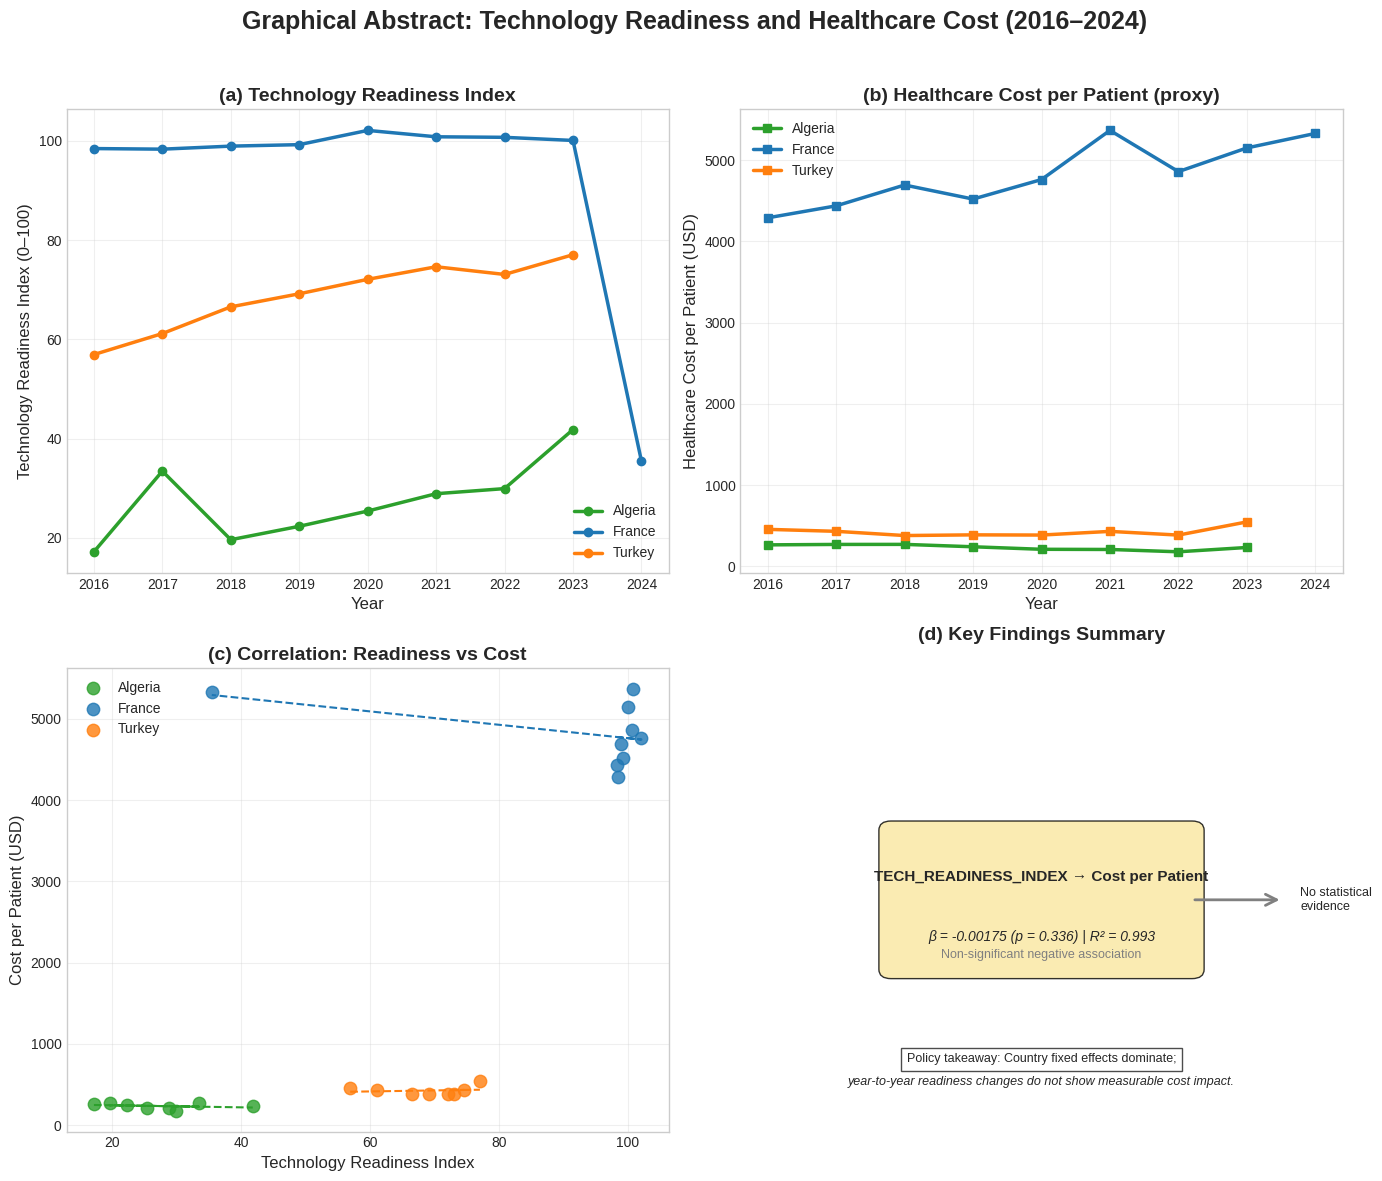

✅ Graphical abstract saved as 'graphical_abstract_final.png' and .pdf
📊 Resolution: 300 DPI, ready for publication.


In [5]:
# ============================================================
# GRAPHICAL ABSTRACT – REAL DATA, NON-SIGNIFICANT FINDINGS
# Algeria, France, Turkey (2016–2024)
# For MIDe 2026 / Elsevier submission
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ------------------------------
# 1. LOAD REAL DATA
# ------------------------------
df = pd.read_csv('healthcare_panel_REAL_DATA_2016_2024.csv')
df = df.sort_values(['country', 'year'])

# Ensure numeric
df['tech_readiness_index'] = pd.to_numeric(df['tech_readiness_index'], errors='coerce')
df['log_cost_per_patient'] = pd.to_numeric(df['log_cost_per_patient'], errors='coerce')
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Drop rows with missing critical values (if any)
df = df.dropna(subset=['country', 'year', 'tech_readiness_index', 'log_cost_per_patient'])

# ------------------------------
# 2. GLOBAL STYLE
# ------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
colors = {'Algeria': '#2ca02c', 'France': '#1f77b4', 'Turkey': '#ff7f0e'}

# ------------------------------
# 3. CREATE 2x2 SUBPLOTS
# ------------------------------
fig = plt.figure(figsize=(14, 12))
fig.suptitle('Graphical Abstract: Technology Readiness and Healthcare Cost (2016–2024)',
             fontsize=18, fontweight='bold', y=0.98)

# ----- (a) TECH_READINESS_INDEX over time -----
ax1 = fig.add_subplot(2, 2, 1)
for c in df['country'].unique():
    sub = df[df['country'] == c]
    ax1.plot(sub['year'], sub['tech_readiness_index'], marker='o', linewidth=2.5,
             label=c, color=colors[c])
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Technology Readiness Index (0–100)', fontsize=12)
ax1.set_title('(a) Technology Readiness Index', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(alpha=0.3)

# ----- (b) Cost per patient over time (proxy) -----
ax2 = fig.add_subplot(2, 2, 2)
df['cost_per_patient_USD'] = np.exp(df['log_cost_per_patient'])  # back-transform
for c in df['country'].unique():
    sub = df[df['country'] == c]
    ax2.plot(sub['year'], sub['cost_per_patient_USD'], marker='s', linewidth=2.5,
             label=c, color=colors[c])
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Healthcare Cost per Patient (USD)', fontsize=12)
ax2.set_title('(b) Healthcare Cost per Patient (proxy)', fontsize=14, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(alpha=0.3)

# ----- (c) Scatter: TECH_READINESS_INDEX vs Cost (with linear fits) -----
ax3 = fig.add_subplot(2, 2, 3)
for c in df['country'].unique():
    sub = df[df['country'] == c]
    ax3.scatter(sub['tech_readiness_index'], sub['cost_per_patient_USD'],
                label=c, s=80, color=colors[c], alpha=0.8)
    # Linear trend line
    z = np.polyfit(sub['tech_readiness_index'], sub['cost_per_patient_USD'], 1)
    p = np.poly1d(z)
    ax3.plot(sub['tech_readiness_index'], p(sub['tech_readiness_index']),
             linestyle='--', linewidth=1.5, color=colors[c])
ax3.set_xlabel('Technology Readiness Index', fontsize=12)
ax3.set_ylabel('Cost per Patient (USD)', fontsize=12)
ax3.set_title('(c) Correlation: Readiness vs Cost', fontsize=14, fontweight='bold')
ax3.legend(loc='best')
ax3.grid(alpha=0.3)

# ----- (d) Key Findings Summary (non-significant result) -----
ax4 = fig.add_subplot(2, 2, 4)
ax4.set_xlim(0, 10)
ax4.set_ylim(0, 10)
ax4.axis('off')
ax4.set_title('(d) Key Findings Summary', fontsize=14, fontweight='bold', pad=20)

# Draw central box
box = FancyBboxPatch((2.5, 3.5), 5, 3, boxstyle="round,pad=0.2",
                     edgecolor="black", facecolor="#f9e79f", alpha=0.8)
ax4.add_patch(box)
ax4.text(5, 5.5, 'TECH_READINESS_INDEX → Cost per Patient', ha='center', va='center',
         fontsize=11, fontweight='bold')
ax4.text(5, 4.2, 'β = -0.00175 (p = 0.336) | R² = 0.993', ha='center', va='center',
         fontsize=10, style='italic')
ax4.text(5, 3.8, 'Non‑significant negative association', ha='center', va='center',
         fontsize=9, color='gray')

# Arrow indicating null result
arrow = FancyArrowPatch((7.5, 5), (9, 5), arrowstyle='->', mutation_scale=20,
                        linewidth=2, color='gray')
ax4.add_patch(arrow)
ax4.text(9.3, 5, 'No statistical\nevidence', ha='left', va='center', fontsize=9,
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# Policy takeaway
ax4.text(5, 1.5, 'Policy takeaway: Country fixed effects dominate;', ha='center',
         fontsize=9, bbox=dict(facecolor='white', alpha=0.7))
ax4.text(5, 1.0, 'year‑to‑year readiness changes do not show measurable cost impact.',
         ha='center', fontsize=9, style='italic')

plt.tight_layout(rect=[0, 0, 1, 0.96])

# ------------------------------
# 4. SAVE HIGH-RESOLUTION IMAGES
# ------------------------------
plt.savefig('graphical_abstract_final.png', dpi=300, bbox_inches='tight')
plt.savefig('graphical_abstract_final.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graphical abstract saved as 'graphical_abstract_final.png' and .pdf")
print("📊 Resolution: 300 DPI, ready for publication.")
